In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("Note: xgboost not installed, skipping XGBoost.")

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("Note: lightgbm not installed, skipping LightGBM.")


df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df = df.drop(columns=['Id'])

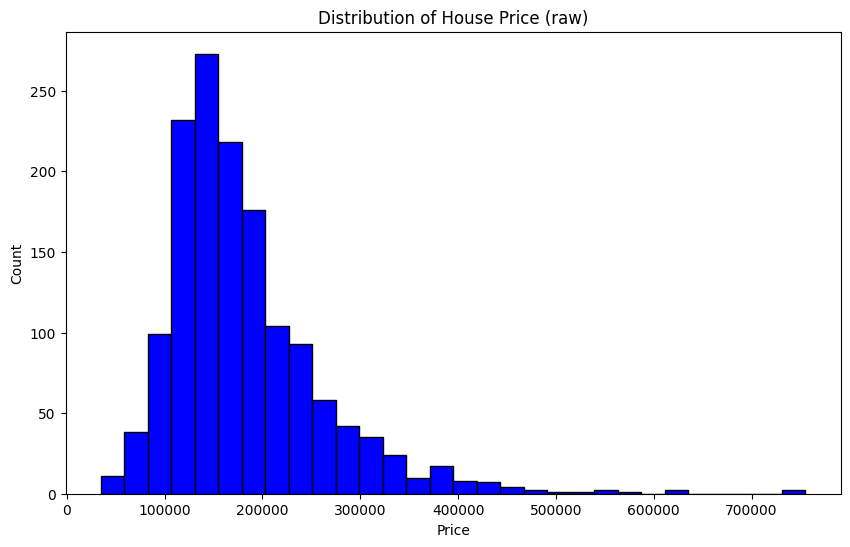

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(df['SalePrice'], bins=30, color='blue', edgecolor='black')
plt.title('Distribution of House Price (raw)')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()


In [7]:
check_skew = skew(df['SalePrice'])
print(f"\nSalePrice skewness (raw):   {check_skew:.3f}")


SalePrice skewness (raw):   1.881


In [8]:
df['SalePrice'] = (np.log1p(df['SalePrice']))

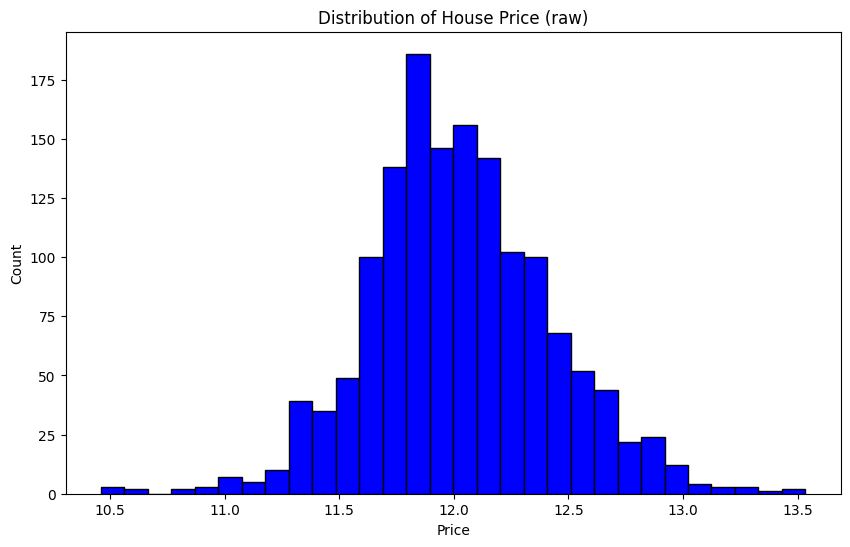

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(df['SalePrice'], bins=30, color='blue', edgecolor='black')
plt.title('Distribution of House Price (raw)')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

In [10]:
df['MSSubClass'].value_counts()

MSSubClass
20     536
60     299
50     144
120     87
30      69
160     63
70      60
80      58
90      52
190     30
85      20
75      16
45      12
180     10
40       4
Name: count, dtype: int64

In [11]:
mssubclass_map = {
    20: '1-STORY 1946 & NEWER ALL STYLES',
    30: '1-STORY 1945 & OLDER',
    40: '1-STORY W/FINISHED ATTIC ALL AGES',
    45: '1-1/2 STORY - UNFINISHED ALL AGES',
    50: '1-1/2 STORY FINISHED ALL AGES',
    60: '2-STORY 1946 & NEWER',
    70: '2-STORY 1945 & OLDER',
    75: '2-1/2 STORY ALL AGES',
    80: 'SPLIT OR MULTI-LEVEL',
    85: 'SPLIT FOYER',
    90: 'DUPLEX - ALL STYLES AND AGES',
    120: '1-STORY PUD - 1946 & NEWER',
    150: '1-1/2 STORY PUD - ALL AGES',
    160: '2-STORY PUD - 1946 & NEWER',
    180: 'PUD - MULTILEVEL - INCL SPLIT LEV/FOYER',
    190: '2 FAMILY CONVERSION - ALL STYLES AND AGES'
}

df['MSSubClass'] = df['MSSubClass'].map(mssubclass_map)


In [12]:
df['MSSubClass'].value_counts()
df['MSSubClass'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1460 entries, 0 to 1459
Series name: MSSubClass
Non-Null Count  Dtype 
--------------  ----- 
1460 non-null   object
dtypes: object(1)
memory usage: 11.5+ KB


In [13]:
df['MasVnrType']  = df['MasVnrType'].fillna('None')
df['GarageType']  = df['GarageType'].fillna('NA')
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['Electrical']  = df['Electrical'].fillna('SBrkr')
df['BsmtFinType1'] = df['BsmtFinType1'].fillna('NA')
df['BsmtFinType2'] = df['BsmtFinType2'].fillna('NA')
df['BsmtExposure'] = df['BsmtExposure'].fillna('NA')
df['BsmtQual'] = df['BsmtQual'].fillna('NA')
df['BsmtCond'] = df['BsmtCond'].fillna('NA')
df['GarageCond'] = df['GarageCond'].fillna('NA')
df['GarageQual'] = df['GarageQual'].fillna('NA')
df['GarageFinish'] = df['GarageFinish'].fillna('NA')
df['MasVnrArea']  = df['MasVnrArea'].fillna(df['MasVnrArea'].median())

In [14]:
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}

qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
             'HeatingQC', 'KitchenQual', 'FireplaceQu',
             'GarageQual', 'GarageCond', 'PoolQC']

for col in qual_cols:
    df[col] = df[col].fillna('NA').map(quality_map)


df['OverallQualScore'] = df[qual_cols].sum(axis=1)

In [15]:

df['NumberFloors'] = 1 + (df['2ndFlrSF'] > 0).astype(int)
df['TotalSqf'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']
df = df.drop(columns=['1stFlrSF', '2ndFlrSF', 'TotalBsmtSF'])
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']
df['Remodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)
df['TotalPorchSF'] = (df['WoodDeckSF'] + df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'])
df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)



In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 87 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MSSubClass         1460 non-null   object 
 1   MSZoning           1460 non-null   object 
 2   LotFrontage        1460 non-null   float64
 3   LotArea            1460 non-null   int64  
 4   Street             1460 non-null   object 
 5   Alley              91 non-null     object 
 6   LotShape           1460 non-null   object 
 7   LandContour        1460 non-null   object 
 8   Utilities          1460 non-null   object 
 9   LotConfig          1460 non-null   object 
 10  LandSlope          1460 non-null   object 
 11  Neighborhood       1460 non-null   object 
 12  Condition1         1460 non-null   object 
 13  Condition2         1460 non-null   object 
 14  BldgType           1460 non-null   object 
 15  HouseStyle         1460 non-null   object 
 16  OverallQual        1460 

In [17]:
df = df.drop(columns=['MiscFeature', 'Alley', 'Fence','FireplaceQu','PoolQC'])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MSSubClass         1460 non-null   object 
 1   MSZoning           1460 non-null   object 
 2   LotFrontage        1460 non-null   float64
 3   LotArea            1460 non-null   int64  
 4   Street             1460 non-null   object 
 5   LotShape           1460 non-null   object 
 6   LandContour        1460 non-null   object 
 7   Utilities          1460 non-null   object 
 8   LotConfig          1460 non-null   object 
 9   LandSlope          1460 non-null   object 
 10  Neighborhood       1460 non-null   object 
 11  Condition1         1460 non-null   object 
 12  Condition2         1460 non-null   object 
 13  BldgType           1460 non-null   object 
 14  HouseStyle         1460 non-null   object 
 15  OverallQual        1460 non-null   int64  
 16  OverallCond        1460 

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
neighborhood_means = y_train.groupby(X_train['Neighborhood']).mean()


In [21]:
X_train['NeighborhoodEncoded'] = X_train['Neighborhood'].map(neighborhood_means)
X_test['NeighborhoodEncoded']  = X_test['Neighborhood'].map(neighborhood_means)

In [22]:
overall_train_mean = y_train.mean()
X_test['NeighborhoodEncoded'] = X_test['NeighborhoodEncoded'].fillna(overall_train_mean)


In [23]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()

print(f"Categorical columns: {len(cat_cols)}")  # should still include 'Neighborhood' (raw)
print(f"Numerical columns:   {len(num_cols)}")  # should now include 'NeighborhoodEncoded'



Categorical columns: 31
Numerical columns:   51


In [24]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


In [25]:
cat_pipeline.fit(X_train[cat_cols])
ohe = cat_pipeline.named_steps['encoder']
cat_feature_names = ohe.get_feature_names_out(cat_cols)

In [26]:
X_train_cat_encoded = cat_pipeline.transform(X_train[cat_cols])

In [27]:
df_encoded_train = pd.DataFrame(X_train_cat_encoded, columns=cat_feature_names, index=X_train.index)
df_encoded_train = pd.concat([df_encoded_train, X_train[num_cols]], axis=1)

In [28]:
df_encoded_train['SalePrice'] = y_train.values
correlations = df_encoded_train.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
print(correlations)


SalePrice              1.000000
OverallQual            0.807946
OverallQualScore       0.790669
TotalSqf               0.761812
NeighborhoodEncoded    0.744358
                         ...   
MasVnrType_None       -0.371140
GarageType_Detchd     -0.374837
GarageFinish_Unf      -0.423677
YearsSinceRemodel     -0.563856
HouseAge              -0.577002
Name: SalePrice, Length: 268, dtype: float64


In [29]:
for name, value in correlations.items():
    print(f"{name:40s} {value:.6f}")

SalePrice                                1.000000
OverallQual                              0.807946
OverallQualScore                         0.790669
TotalSqf                                 0.761812
NeighborhoodEncoded                      0.744358
GrLivArea                                0.689012
GarageCars                               0.684451
KitchenQual                              0.667939
ExterQual                                0.660159
GarageArea                               0.654520
BsmtQual                                 0.622365
FullBath                                 0.583747
YearBuilt                                0.576725
GarageYrBlt                              0.563325
YearRemodAdd                             0.562152
TotRmsAbvGrd                             0.520082
Foundation_PConc                         0.518922
HasFireplace                             0.507096
HeatingQC                                0.484609
Fireplaces                               0.481761


In [30]:
# 1. Build df_encoded_test the same way we built df_encoded_train (train-fit encoder, transform test)
X_test_cat_encoded = cat_pipeline.transform(X_test[cat_cols])
df_encoded_test = pd.DataFrame(X_test_cat_encoded, columns=cat_feature_names, index=X_test.index)
df_encoded_test = pd.concat([df_encoded_test, X_test[num_cols]], axis=1)

# 2. Identify weak columns directly from the encoded correlation list
threshold = 0.05
corr_no_target = correlations.drop('SalePrice')
weak_cols = corr_no_target[corr_no_target.abs() < threshold].index.tolist()

print(f"Dropping {len(weak_cols)} weak columns (|corr| < {threshold})")

# 3. Drop directly from BOTH encoded frames (train and test), keeping them aligned
df_encoded_train_trimmed = df_encoded_train.drop(columns=weak_cols + ['SalePrice'], errors='ignore')
df_encoded_test_trimmed  = df_encoded_test.drop(columns=weak_cols, errors='ignore')

print(f"X_train_processed shape: {df_encoded_train_trimmed.shape}")
print(f"X_test_processed shape:  {df_encoded_test_trimmed.shape}")

# 4. Scale numeric columns (still needed since we skipped the num_pipeline scaler)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_processed = scaler.fit_transform(df_encoded_train_trimmed)
X_test_processed  = scaler.transform(df_encoded_test_trimmed)

print(f"\nFinal X_train_processed shape: {X_train_processed.shape}")
print(f"Final X_test_processed shape:  {X_test_processed.shape}")

Dropping 88 weak columns (|corr| < 0.05)
X_train_processed shape: (1168, 179)
X_test_processed shape:  (292, 179)

Final X_train_processed shape: (1168, 179)
Final X_test_processed shape:  (292, 179)


In [31]:

models = {
    # --- Simple / Linear ---
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(),
    "Lasso Regression":  Lasso(),
    "ElasticNet":        ElasticNet(),

    # --- Medium / Single Tree ---
    "Decision Tree":     DecisionTreeRegressor(random_state=42),

    # --- Complex / Ensemble ---
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
}

if HAS_XGB:
    models["XGBoost"] = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)
if HAS_LGBM:
    models["LightGBM"] = LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)


In [32]:
# 3. Define the Param Grids
quick_param_grids = {
    "Linear Regression": {},
    "Ridge Regression": {
        'alpha':  [0.01, 0.1, 1.0, 10.0, 100.0],
        'solver': ['auto', 'svd', 'lsqr'],
    },
    "Lasso Regression": {
        'alpha':     [0.00001, 0.0001, 0.001, 0.01, 0.1],
        'selection': ['cyclic', 'random'],
    },
    "ElasticNet": {
        'alpha':     [0.00001, 0.0001, 0.001, 0.01, 0.1],
        'l1_ratio':  [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        'selection': ['cyclic', 'random'],
    },
    "Decision Tree": {
        'max_depth':       [3, 5, 8, 12, None],
        'min_samples_leaf': [1, 5, 10, 20],
        'max_features':    ['sqrt', 'log2', None],
    },
    "Random Forest": {
        'n_estimators':    [50, 100, 200],
        'max_depth':       [5, 10, 20, None],
        'min_samples_leaf': [1, 5, 10],
        'max_features':    ['sqrt', 'log2'],
    },
    "Gradient Boosting": {
        'n_estimators':  [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth':     [2, 3, 5],
        'subsample':     [0.7, 0.85, 1.0],
    },
    "XGBoost": {
        'n_estimators':     [50, 100, 200],
        'learning_rate':    [0.01, 0.05, 0.1],
        'max_depth':        [3, 5, 7],
        'subsample':        [0.7, 0.85, 1.0],
        'colsample_bytree': [0.7, 0.85, 1.0],
    },
    "LightGBM": {
        'n_estimators':      [50, 100, 200],
        'learning_rate':     [0.01, 0.05, 0.1],
        'num_leaves':        [15, 31, 63, 127],
        'min_child_samples': [5, 20, 50],
        'subsample':         [0.7, 0.85, 1.0],
        'verbose':           [-1]
    },
}

In [33]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# 4. Run the Tuning Loop
tuned_results = []
tuned_models  = {}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    param_grid = quick_param_grids.get(name, {})

    if not param_grid:
        best_model = model
        best_model.fit(X_train_processed, y_train)
        best_params = {}
    else:
        base_estimator = clone(model)

        if name in ["Lasso Regression", "ElasticNet"]:
            base_estimator.set_params(max_iter=10000, tol=1e-3)

        gs = GridSearchCV(
            estimator=base_estimator,
            param_grid=param_grid,
            cv=cv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            verbose=0
        )
        gs.fit(X_train_processed, y_train)

        best_model  = gs.best_estimator_
        best_params = gs.best_params_

    tuned_models[name] = best_model

    y_pred_train = best_model.predict(X_train_processed)
    y_pred_test  = best_model.predict(X_test_processed)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
    r2_train   = r2_score(y_train, y_pred_train)
    r2_test    = r2_score(y_test,  y_pred_test)
    rmse_gap   = rmse_test - rmse_train
    rmse_ratio = rmse_test / rmse_train


    tuned_results.append({
        "Model":       name,
        "Best Params": str(best_params) if best_params else "defaults",
        "Train RMSE":  round(rmse_train, 4),
        "Test RMSE":   round(rmse_test,  4),
        "RMSE Gap":    round(rmse_gap, 4),
        "RMSE Ratio":  round(rmse_ratio, 4),
        "Train R2":    round(r2_train, 4),
        "Test R2":     round(r2_test,  4),
    })
    print(f"  Done: {name}  best={best_params}")

  Done: Linear Regression  best={}


  Done: Ridge Regression  best={'alpha': 100.0, 'solver': 'auto'}


  Done: Lasso Regression  best={'alpha': 0.001, 'selection': 'cyclic'}


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.755272e+00, tolerance: 1.413e-01
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.505501e+00, tolerance: 1.395e-01
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number o

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.174492e+00, tolerance: 1.386e-01
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.724219e+00, tolerance: 1.386e-01
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number o

...

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/skle

  Done: LightGBM  best={'learning_rate': 0.05, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 15, 'subsample': 0.7, 'verbose': -1}


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [34]:
# 5. Output Leaderboard
tuned_leaderboard = pd.DataFrame(tuned_results).sort_values("Test RMSE")
print("\n=== Tuned Model Leaderboard (sorted by Test RMSE) ===")
print(tuned_leaderboard[["Model", "Train RMSE", "Test RMSE", "RMSE Gap", "RMSE Ratio", "Train R2", "Test R2"]].to_string(index=False))

tuned_champion_row   = tuned_leaderboard.iloc[0]
tuned_champion_name  = tuned_champion_row["Model"]
tuned_best_params    = tuned_champion_row["Best Params"]

print(f"\n{'='*60}")
print(f"TUNED CHAMPION: {tuned_champion_name}")
print(f"Best params from quick search: {tuned_best_params}")
print(f"Test RMSE:  {tuned_champion_row['Test RMSE']}  |  Test R2: {tuned_champion_row['Test R2']}")
print(f"RMSE Gap:   {tuned_champion_row['RMSE Gap']}")
print(f"RMSE Ratio: {tuned_champion_row['RMSE Ratio']}")
print(f"{'='*60}")


=== Tuned Model Leaderboard (sorted by Test RMSE) ===
            Model  Train RMSE  Test RMSE  RMSE Gap  RMSE Ratio  Train R2  Test R2
 Lasso Regression      0.1132     0.1255    0.0123      1.1087    0.9159   0.9156
Linear Regression      0.1101     0.1268    0.0168      1.1524    0.9205   0.9138
       ElasticNet      0.1195     0.1276    0.0082      1.0686    0.9064   0.9127
 Ridge Regression      0.1148     0.1280    0.0131      1.1143    0.9135   0.9123
          XGBoost      0.0660     0.1332    0.0673      2.0201    0.9715   0.9049
Gradient Boosting      0.0784     0.1350    0.0566      1.7223    0.9597   0.9024
         LightGBM      0.0638     0.1382    0.0744      2.1659    0.9733   0.8977
    Random Forest      0.0512     0.1513    0.1001      2.9556    0.9828   0.8774
    Decision Tree      0.1183     0.1838    0.0655      1.5539    0.9083   0.8190

TUNED CHAMPION: Lasso Regression
Best params from quick search: {'alpha': 0.001, 'selection': 'cyclic'}
Test RMSE:  0.1255  

In [35]:
from sklearn.linear_model import Lasso

print("Starting deep grid search for Lasso Regression...")

# 1. Lasso hyperparameter grid — alpha controls regularization strength
#    Lasso tends to need smaller alphas than Ridge since its penalty is more aggressive
#    (it can zero out coefficients entirely, unlike Ridge which only shrinks them)
deep_param_grid = {
    'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    'selection': ['cyclic', 'random']
}

n_combos = 1
for v in deep_param_grid.values():
    n_combos *= len(v)
print(f"Testing {n_combos} combinations...\n")

# 2. Setup the grid search
#    max_iter/tol bumped up since Lasso uses coordinate descent and can need more
#    iterations to converge, especially with many features (like your one-hot columns)
lasso_base = Lasso(random_state=42, max_iter=10000, tol=1e-3)

deep_gs = GridSearchCV(
    estimator=lasso_base,
    param_grid=deep_param_grid,
    cv=cv,  # Reusing your KFold from earlier
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# 3. Fit the model
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    deep_gs.fit(X_train_processed, y_train)

# 4. Extract and evaluate the ultimate champion
deep_champ = deep_gs.best_estimator_

y_pred_train_deep = deep_champ.predict(X_train_processed)
y_pred_test_deep  = deep_champ.predict(X_test_processed)

rmse_train_deep = np.sqrt(mean_squared_error(y_train, y_pred_train_deep))
rmse_test_deep  = np.sqrt(mean_squared_error(y_test,  y_pred_test_deep))
r2_train_deep   = r2_score(y_train, y_pred_train_deep)
r2_test_deep    = r2_score(y_test,  y_pred_test_deep)
rmse_gap_deep   = rmse_test_deep - rmse_train_deep
rmse_ratio_deep = rmse_test_deep / rmse_train_deep

# 5. Print the final results
print(f"\n{'='*60}")
print("DEEP TUNED LASSO REGRESSION")
print(f"Best Params: {deep_gs.best_params_}")
print(f"{'-'*60}")
print(f"Train RMSE: {rmse_train_deep:.4f}  |  Test RMSE: {rmse_test_deep:.4f}")
print(f"Train R2:   {r2_train_deep:.4f}  |  Test R2:   {r2_test_deep:.4f}")
print(f"RMSE Gap:   {rmse_gap_deep:.4f} (Previous Lasso gap was ~0.0118)")
print(f"RMSE Ratio: {rmse_ratio_deep:.4f} (Previous Lasso ratio was ~1.10)")
print(f"{'='*60}")

Starting deep grid search for Lasso Regression...
Testing 22 combinations...

Fitting 5 folds for each of 22 candidates, totalling 110 fits



DEEP TUNED LASSO REGRESSION
Best Params: {'alpha': 0.005, 'selection': 'cyclic'}
------------------------------------------------------------
Train RMSE: 0.1233  |  Test RMSE: 0.1300
Train R2:   0.9002  |  Test R2:   0.9094
RMSE Gap:   0.0067 (Previous Lasso gap was ~0.0118)
RMSE Ratio: 1.0540 (Previous Lasso ratio was ~1.10)


In [36]:
from sklearn.linear_model import LassoCV
import time

print("Starting LassoCV — automatic alpha path search...")

t0 = time.time()

# LassoCV automatically searches along a path of alpha values
# rather than testing a fixed list — generally more thorough and efficient
lasso_cv = LassoCV(
    # alphas left at its default (100), which auto-generates the alpha path
    cv=cv,             # reusing your KFold from earlier
    max_iter=10000,
    tol=1e-3,
    random_state=42,
    n_jobs=-1
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lasso_cv.fit(X_train_processed, y_train)

fit_time = time.time() - t0
print(f"Fit completed in {fit_time:.2f}s")
print(f"Optimal alpha found: {lasso_cv.alpha_:.6f}\n")

# Evaluate the champion
y_pred_train_deep = lasso_cv.predict(X_train_processed)
y_pred_test_deep  = lasso_cv.predict(X_test_processed)

rmse_train_deep = np.sqrt(mean_squared_error(y_train, y_pred_train_deep))
rmse_test_deep  = np.sqrt(mean_squared_error(y_test,  y_pred_test_deep))
r2_train_deep   = r2_score(y_train, y_pred_train_deep)
r2_test_deep    = r2_score(y_test,  y_pred_test_deep)
rmse_gap_deep   = rmse_test_deep - rmse_train_deep
rmse_ratio_deep = rmse_test_deep / rmse_train_deep

# Print the final results
print(f"{'='*60}")
print("LASSOCV — OPTIMAL ALPHA PATH SEARCH")
print(f"Best Alpha: {lasso_cv.alpha_:.6f}")
print(f"{'-'*60}")
print(f"Train RMSE: {rmse_train_deep:.4f}  |  Test RMSE: {rmse_test_deep:.4f}")
print(f"Train R2:   {r2_train_deep:.4f}  |  Test R2:   {r2_test_deep:.4f}")
print(f"RMSE Gap:   {rmse_gap_deep:.4f} (Previous best gap was ~0.0072-0.0118)")
print(f"RMSE Ratio: {rmse_ratio_deep:.4f} (Previous best ratio was ~1.06-1.10)")
print(f"{'='*60}")

Starting LassoCV — automatic alpha path search...
Fit completed in 0.06s
Optimal alpha found: 0.002744

LASSOCV — OPTIMAL ALPHA PATH SEARCH
Best Alpha: 0.002744
------------------------------------------------------------
Train RMSE: 0.1187  |  Test RMSE: 0.1275
Train R2:   0.9075  |  Test R2:   0.9129
RMSE Gap:   0.0088 (Previous best gap was ~0.0072-0.0118)
RMSE Ratio: 1.0739 (Previous best ratio was ~1.06-1.10)


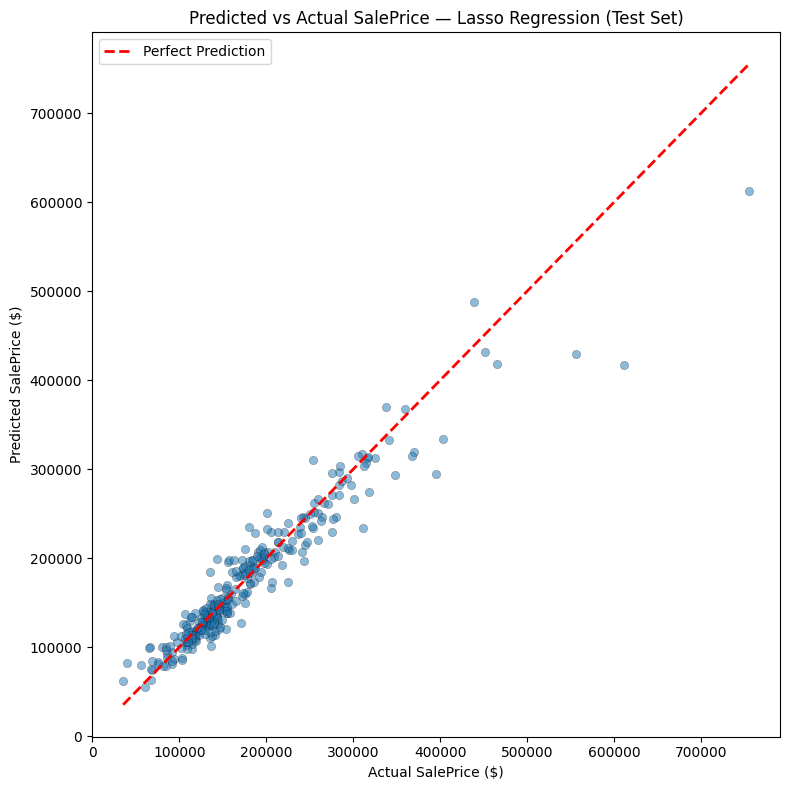

In [37]:
import matplotlib.pyplot as plt
import numpy as np

y_pred_test_log = lasso_cv.predict(X_test_processed)

# Convert back from log1p to actual dollar scale
y_test_dollars = np.expm1(y_test)
y_pred_test_dollars = np.expm1(y_pred_test_log)

plt.figure(figsize=(8, 8))
plt.scatter(y_test_dollars, y_pred_test_dollars, alpha=0.5, edgecolor='k', linewidth=0.3)

min_val = min(y_test_dollars.min(), y_pred_test_dollars.min())
max_val = max(y_test_dollars.max(), y_pred_test_dollars.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual SalePrice ($)')
plt.ylabel('Predicted SalePrice ($)')
plt.title('Predicted vs Actual SalePrice — Lasso Regression (Test Set)')
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
import pandas as pd
import numpy as np

# ============================================================
# 1. Actual vs Predicted Table
# ============================================================
y_pred_test_log = lasso_cv.predict(X_test_processed)

y_test_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_pred_test_log)

comparison_df = pd.DataFrame({
    'Actual SalePrice': y_test_dollars.values,
    'Predicted SalePrice': y_pred_dollars,
    'Error ($)': y_pred_dollars - y_test_dollars.values,
    'Abs Error ($)': np.abs(y_pred_dollars - y_test_dollars.values),
    'Error (%)': ((y_pred_dollars - y_test_dollars.values) / y_test_dollars.values) * 100
}, index=y_test.index)

comparison_df = comparison_df.sort_values('Abs Error ($)', ascending=False)

# --- Summary stats ---
avg_abs_error = comparison_df['Abs Error ($)'].mean()
avg_pct_error = comparison_df['Error (%)'].abs().mean() # mean absolute percentage error (MAPE)

print(f"\n{'='*60}")
print(f"Average Absolute Error: ${avg_abs_error:,.2f}")
print(f"Average Absolute % Error (MAPE): {avg_pct_error:.2f}%")
print(f"{'='*60}")

print("=== Actual vs Predicted SalePrice (sorted by largest error) ===")
print(comparison_df.round(2).to_string())

# Optional: save to CSV for easier review
comparison_df.round(2).to_csv('actual_vs_predicted.csv')
print("\nSaved to actual_vs_predicted.csv")


Average Absolute Error: $15,821.96
Average Absolute % Error (MAPE): 9.23%
=== Actual vs Predicted SalePrice (sorted by largest error) ===
      Actual SalePrice  Predicted SalePrice  Error ($)  Abs Error ($)  Error (%)
898           611657.0            416789.62 -194867.38      194867.38     -31.86
691           755000.0            612859.49 -142140.51      142140.51     -18.83
1046          556581.0            429956.80 -126624.20      126624.20     -22.75
774           395000.0            294618.71 -100381.29      100381.29     -25.41
218           311500.0            233972.50  -77527.50       77527.50     -24.89
231           403000.0            334244.96  -68755.04       68755.04     -17.06
581           253293.0            310751.75   57458.75       57458.75      22.68
588           143000.0            199099.84   56099.84       56099.84      39.23
744           180000.0            235072.83   55072.83       55072.83      30.60
990           348000.0            293399.36  -54600

In [39]:
# ============================================================
# 2. Feature Importance (Lasso Coefficients)
# ============================================================
# Get the feature names in the exact order they appear in X_train_processed
feature_names = df_encoded_train_trimmed.columns.tolist()

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_cv.coef_
})

# Sort by actual coefficient value, highest (most positive) to lowest (most negative)
coef_df = coef_df.sort_values('Coefficient', ascending=False)

# How many features did Lasso zero out entirely? (its built-in feature selection)
zeroed_out = (coef_df['Coefficient'] == 0).sum()
print(f"\n=== Lasso Feature Importance (Coefficients) ===")
print(f"Total features: {len(coef_df)}")
print(f"Features zeroed out by Lasso: {zeroed_out}")
print(f"Features retained: {len(coef_df) - zeroed_out}\n")

# Top 5 positive and top 10 negative
top5_positive = coef_df.head(10)
top5_negative = coef_df.tail(10)

print("Top 10 Positive Features (increase SalePrice):")
print(top5_positive.to_string(index=False))

print("\nTop 10 Negative Features (decrease SalePrice):")
print(top5_negative.to_string(index=False))

coef_df.to_csv('lasso_feature_importance.csv', index=False)
print("\nFull list saved to lasso_feature_importance.csv")


=== Lasso Feature Importance (Coefficients) ===
Total features: 179
Features zeroed out by Lasso: 85
Features retained: 94

Top 10 Positive Features (increase SalePrice):
                                   Feature  Coefficient
                                 GrLivArea     0.097043
                               OverallQual     0.078728
                       NeighborhoodEncoded     0.049382
                          OverallQualScore     0.046008
                                GarageCars     0.035475
                              BsmtFullBath     0.022271
MSSubClass_1-STORY 1946 & NEWER ALL STYLES     0.017501
                       Exterior1st_BrkFace     0.017113
                              TotalPorchSF     0.016530
                              TotRmsAbvGrd     0.015031

Top 10 Negative Features (decrease SalePrice):
                              Feature  Coefficient
                SaleCondition_Abnorml    -0.010269
                      LandContour_Bnk    -0.010846
           